In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from mad.utils import load_ballistic_table, BALLISTIC_FIELD_NAMES
from mad.configs.planets import EARTH_SETTINGS
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [38]:
ballistic_values = load_ballistic_table("titan_stage_2")
df = pd.DataFrame({k:ballistic_values.table[:, i] for i, k in enumerate(BALLISTIC_FIELD_NAMES)})

In [39]:

df["range_km"] = df["range_rad"] * EARTH_SETTINGS["radius"] / 1000
df["altitude_km"] = df["altitude_m"] / 1000
df["gamma_deg"] = df["gamma_rad"] * 180 / np.pi


In [42]:
selected_altitude = 100
df2 = df[df["altitude_km"] == selected_altitude].pivot(index="velocity_m_s", columns="gamma_deg", values="range_km")
df2.head(5)


gamma_deg,20.0,25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0,75.0,80.0,85.0
velocity_m_s,,,,,,,,,,,,,,
500.0,65.216311,65.129798,64.341359,62.803044,60.481347,57.359754,53.440607,48.746170,43.318888,37.220839,30.532438,23.350477,15.785567,7.959127
1000.0,150.696866,155.616084,158.502440,159.021411,156.916198,152.019932,144.261415,133.666077,120.353262,104.530486,86.485177,66.574312,45.212383,22.858069
1500.0,262.264564,278.826841,291.017632,297.912015,298.841542,293.394532,281.410121,262.966616,238.364039,208.101961,172.854036,133.440480,90.799355,45.957294
2000.0,407.117501,442.900399,470.402708,487.885814,494.172685,488.615722,471.057532,441.781843,401.459077,351.090322,291.952123,225.543566,153.536429,77.728544
2500.0,593.713100,656.947321,705.806542,737.593004,750.657642,744.282838,718.555017,674.238160,612.654206,535.573830,445.119695,343.682894,233.852034,118.353407


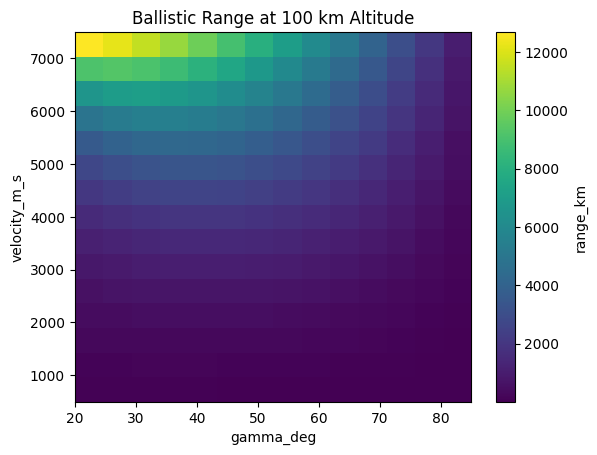

In [43]:
fig, ax = plt.subplots()
img = ax.imshow(df2.values, extent=(df2.columns.min(), df2.columns.max(), df2.index.min(), df2.index.max()), aspect="auto", origin="lower")
ax.set_xlabel("gamma_deg")
ax.set_ylabel("velocity_m_s")
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("range_km")
ax.set_title(f"Ballistic Range at {selected_altitude} km Altitude")
plt.show()

In [ ]:
df[(20 < df["range_km"]) & (df["range_km"] < 30)]